In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score

In [ ]:
ruta_base = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Primer Parcial/emozionalmente"

print(os.listdir(ruta_base))

['README.txt', 'metadata', 'audio']


In [ ]:
ruta_audio = os.path.join(ruta_base, "audio")
ruta_metadata = os.path.join(ruta_base, "metadata")

print("AUDIO:")
print(os.listdir(ruta_audio)[:20])

print("\nMETADATA:")
print(os.listdir(ruta_metadata))

AUDIO:
['1614265955239.wav', '1614204971079.wav', '1614196428332.wav', '1613772074309.wav', '1614513074195.wav', '1616245288146.wav', '1613333927164.wav', '1613512958103.wav', '1616245053113.wav', '1613463815651.wav', '1615207418474.wav', '1614013296540.wav', '1613319877805.wav', '1614082398003.wav', '1613305566424.wav', '1613339026273.wav', '1613944977482.wav', '1613646275306.wav', '1616504918027.wav', '1614116955581.wav']

METADATA:
['samples.csv', 'users.csv', 'evaluations.csv', 'split']


In [ ]:
archivos_audio = [f for f in os.listdir(ruta_audio) if f.endswith(".wav")]

print("Cantidad de audios:", len(archivos_audio))
print(archivos_audio[:5])

Cantidad de audios: 6902
['1614265955239.wav', '1614204971079.wav', '1614196428332.wav', '1613772074309.wav', '1614513074195.wav']


In [ ]:
ruta_samples = os.path.join(ruta_metadata, "samples.csv")
samples = pd.read_csv(ruta_samples)

print(samples.shape)
print(samples.columns.tolist())
display(samples.head())

(6902, 5)
['file_name', 'sentence', 'sentence_language', 'actor', 'emotion_expressed']


,file_name,sentence,sentence_language,actor,emotion_expressed
0,1614951631538.wav,E’ andato a scuola dopo pranzo,italian,d4bbc5043503b9aed309ede00854ee48937684b57a1cc0...,anger
1,1613671614352.wav,Tornerà a casa presto,italian,b830cbf6e79aeeeec1fbf2ef3be741628ffc574c9b15f3...,anger
2,1613994293936.wav,Vado in biblioteca,italian,acdd987f9c1700b25898d3bd30c201df5ad4f34b3ca5eb...,anger
3,1617135480050.wav,E’ andato a scuola dopo pranzo,italian,28043d2516f2d956b81ce66cc01fbd427ac54ff1eb3a07...,anger
4,1613658275427.wav,Zia Marta ha detto che devo stare a casa stasera,italian,5b8476bb94a4a1a17df32b417ec035029f48e4487c9055...,anger


In [ ]:
audios_disponibles = set(archivos_audio)

datos = samples[samples["file_name"].isin(audios_disponibles)].copy()

print("Registros metadata:", len(samples))
print("Audios disponibles:", len(archivos_audio))
print("Registros utilizables:", len(datos))
print("Metadata sin audio:", len(samples) - len(datos))

Registros metadata: 6902
Audios disponibles: 6902
Registros utilizables: 6902
Metadata sin audio: 0


In [ ]:
print(datos["emotion_expressed"].unique())
print()
print(datos["emotion_expressed"].value_counts())

['anger' 'disgust' 'fear' 'joy' 'neutrality' 'sadness' 'surprise']

emotion_expressed
anger         986
disgust       986
fear          986
joy           986
neutrality    986
sadness       986
surprise      986
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    datos,
    test_size=0.30,
    stratify=datos["emotion_expressed"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["emotion_expressed"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(valid_df))
print("Test:", len(test_df))

Train: 4831
Validation: 1035
Test: 1036


In [ ]:
encoder = LabelEncoder()
encoder.fit(train_df["emotion_expressed"])

train_df["label"] = encoder.transform(train_df["emotion_expressed"])
valid_df["label"] = encoder.transform(valid_df["emotion_expressed"])
test_df["label"] = encoder.transform(test_df["emotion_expressed"])

print(dict(enumerate(encoder.classes_)))

{0: 'anger', 1: 'disgust', 2: 'fear', 3: 'joy', 4: 'neutrality', 5: 'sadness', 6: 'surprise'}


In [ ]:
def extraer_mfcc(nombre_archivo):
    ruta = os.path.join(ruta_audio, nombre_archivo)
    audio, sr = librosa.load(ruta, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    media = np.mean(mfcc, axis=1)
    desviacion = np.std(mfcc, axis=1)

    return np.concatenate([media, desviacion])

In [ ]:
from tqdm.auto import tqdm

def procesar_dataset(df):
    X = []
    y = []

    for _, fila in tqdm(df.iterrows(), total=len(df)):
        X.append(extraer_mfcc(fila["file_name"]))
        y.append(fila["label"])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

In [ ]:
X_train, y_train = procesar_dataset(train_df)
X_valid, y_valid = procesar_dataset(valid_df)
X_test, y_test = procesar_dataset(test_df)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

  0%|          | 0/4831 [00:00<?, ?it/s]

  0%|          | 0/1035 [00:00<?, ?it/s]

  0%|          | 0/1036 [00:00<?, ?it/s]

Train: (4831, 80) (4831,)
Validation: (1035, 80) (1035,)
Test: (1036, 80) (1036,)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print("Media Train:", X_train.mean())
print("Desviación Train:", X_train.std())

Media Train: -4.9351807e-11
Desviación Train: 0.99999994


Data Augmentation

In [ ]:
ruido = np.random.normal(0, 0.03, X_train.shape)

X_train_aug = np.vstack([X_train, X_train + ruido]).astype(np.float32)
y_train_aug = np.concatenate([y_train, y_train])

X_train_t = torch.tensor(X_train_aug, dtype=torch.float32)
y_train_t = torch.tensor(y_train_aug, dtype=torch.long)
X_valid_t = torch.tensor(X_valid, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid_t, y_valid_t), batch_size=32)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

print(X_train_t.shape)

torch.Size([9662, 80])


BatchNorm + Dropout + arquitectura

In [ ]:
def crear_modelo():
    return nn.Sequential(
        nn.Linear(80, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 7)
    ).to(device)

CrossEntropy + Backprop + Scheduler + Early Stopping

In [ ]:
import copy

def entrenar(modelo, optimizador, epochs=10, paciencia=10):
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizador, step_size=3, gamma=0.5)

    mejor_acc = 0
    espera = 0
    mejor_estado = None
    historial = []

    for epoca in range(epochs):
        modelo.train()

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizador.zero_grad()
            salida = modelo(X)
            loss = loss_fn(salida, y)
            loss.backward()
            optimizador.step()

        modelo.eval()
        correctos = 0
        total = 0

        with torch.no_grad():
            for X, y in valid_loader:
                X, y = X.to(device), y.to(device)
                pred = modelo(X).argmax(1)
                correctos += (pred == y).sum().item()
                total += y.size(0)

        acc = correctos / total
        historial.append(acc)
        scheduler.step()

        if acc > mejor_acc:
            mejor_acc = acc
            mejor_estado = copy.deepcopy(modelo.state_dict())
            espera = 0
        else:
            espera += 1

        if espera >= paciencia:
            break

    modelo.load_state_dict(mejor_estado)

    return mejor_acc, historial

SGD + Momentum + RMSProp + Adam + L2

In [ ]:
resultados = {}

for nombre in ["SGD", "Momentum", "RMSProp", "Adam"]:

    modelo = crear_modelo()

    if nombre == "SGD":
        opt = torch.optim.SGD(modelo.parameters(), lr=0.01, weight_decay=0.001)

    elif nombre == "Momentum":
        opt = torch.optim.SGD(modelo.parameters(), lr=0.01, momentum=0.9, weight_decay=0.001)

    elif nombre == "RMSProp":
        opt = torch.optim.RMSprop(modelo.parameters(), lr=0.001, weight_decay=0.001)

    else:
        opt = torch.optim.Adam(modelo.parameters(), lr=0.001, weight_decay=0.001)

    acc, hist = entrenar(modelo, opt, epochs=10)

    resultados[nombre] = acc

    print(nombre, round(acc, 4))

SGD 0.3816
Momentum 0.4493
RMSProp 0.4435
Adam 0.4319


Modelo Final

In [ ]:
ruta_base = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Primer Parcial/emozionalmente"

modelo_final = crear_modelo()

opt_final = torch.optim.SGD(
    modelo_final.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=0.001
)

acc_final, hist_final = entrenar(
    modelo_final,
    opt_final,
    epochs=20,
    paciencia=5
)

ruta_modelo = os.path.join(ruta_base, "modelo_audio_final.pt")
torch.save(modelo_final.state_dict(), ruta_modelo)

print("Mejor Validation:", round(acc_final, 4))
print("Modelo guardado en:", ruta_modelo)

Mejor Validation: 0.4367
Modelo guardado en: /content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Primer Parcial/emozionalmente/modelo_audio_final.pt


Acurracy-Precision,Recall,Matriz de confusion,F1 Score, Curva Roc

Accuracy: 0.4286
Precision: 0.4375
Recall: 0.4286
F1: 0.4306
ROC-AUC: 0.8134


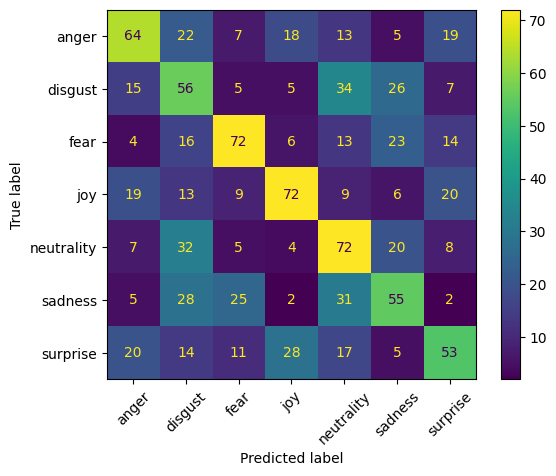

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

modelo_final.eval()

y_real = []
y_pred = []
y_prob = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        salida = modelo_final(X)
        prob = torch.softmax(salida, dim=1)
        pred = prob.argmax(dim=1)

        y_real.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

y_real = np.array(y_real)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

accuracy = accuracy_score(y_real, y_pred)
precision = precision_score(y_real, y_pred, average="macro")
recall = recall_score(y_real, y_pred, average="macro")
f1 = f1_score(y_real, y_pred, average="macro")
roc_auc = roc_auc_score(y_real, y_prob, multi_class="ovr", average="macro")

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

cm = confusion_matrix(y_real, y_pred)
ConfusionMatrixDisplay(cm, display_labels=encoder.classes_).plot()
plt.xticks(rotation=45)
plt.show()

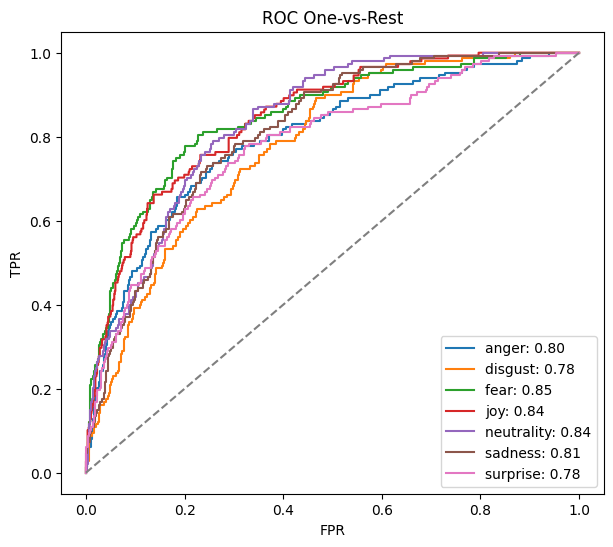

Clase: anger
Threshold: 0.506
TPR: 0.182
FPR: 0.023


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_bin = label_binarize(y_real, classes=np.arange(7))

plt.figure(figsize=(7, 6))

for i, nombre in enumerate(encoder.classes_):
    fpr, tpr, thresholds = roc_curve(y_bin[:, i], y_prob[:, i])
    area = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nombre}: {area:.2f}")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC One-vs-Rest")
plt.legend()
plt.show()

clase = 0
fpr, tpr, thresholds = roc_curve(y_bin[:, clase], y_prob[:, clase])

i = np.argmin(np.abs(thresholds - 0.5))

print("Clase:", encoder.classes_[clase])
print("Threshold:", round(thresholds[i], 3))
print("TPR:", round(tpr[i], 3))
print("FPR:", round(fpr[i], 3))